<a href="https://colab.research.google.com/github/maps-05/portfolio/blob/main/Clustering_Using_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Number 07: Clustering Using PCA

Lab Number 07: Clustering Using PCA

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

random_s = 101

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/renatomaaliw3/public_files/refs/heads/master/Data%20Sets/cluster_mpg.csv")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790,15.6,82,usa,ford mustang gl
388,44.0,4,97.0,52.0,2130,24.6,82,europe,vw pickup
389,32.0,4,135.0,84.0,2295,11.6,82,usa,dodge rampage
390,28.0,4,120.0,79.0,2625,18.6,82,usa,ford ranger


In [ ]:
# Data cleaning

df_cleaned = pd.get_dummies(df, columns=['origin'], dtype=float).drop('name', axis=1)
df_cleaned

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,0.0,0.0,1.0
1,15.0,8,350.0,165.0,3693,11.5,70,0.0,0.0,1.0
2,18.0,8,318.0,150.0,3436,11.0,70,0.0,0.0,1.0
3,16.0,8,304.0,150.0,3433,12.0,70,0.0,0.0,1.0
4,17.0,8,302.0,140.0,3449,10.5,70,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86.0,2790,15.6,82,0.0,0.0,1.0
388,44.0,4,97.0,52.0,2130,24.6,82,1.0,0.0,0.0
389,32.0,4,135.0,84.0,2295,11.6,82,0.0,0.0,1.0
390,28.0,4,120.0,79.0,2625,18.6,82,0.0,0.0,1.0


In [ ]:
# Data scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)
df_scaled


array([[-0.69863841,  1.48394702,  1.07728956, ..., -0.45812285,
        -0.50239045,  0.77459667],
       [-1.08349824,  1.48394702,  1.48873169, ..., -0.45812285,
        -0.50239045,  0.77459667],
       [-0.69863841,  1.48394702,  1.1825422 , ..., -0.45812285,
        -0.50239045,  0.77459667],
       ...,
       [ 1.09737414, -0.86401356, -0.56847897, ..., -0.45812285,
        -0.50239045,  0.77459667],
       [ 0.5842277 , -0.86401356, -0.7120053 , ..., -0.45812285,
        -0.50239045,  0.77459667],
       [ 0.96908753, -0.86401356, -0.72157372, ..., -0.45812285,
        -0.50239045,  0.77459667]])

In [ ]:
df_scaled = pd.DataFrame(df_scaled, columns = df_cleaned.columns)
df_scaled

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
0,-0.698638,1.483947,1.077290,0.664133,0.620540,-1.285258,-1.625315,-0.458123,-0.50239,0.774597
1,-1.083498,1.483947,1.488732,1.574594,0.843334,-1.466724,-1.625315,-0.458123,-0.50239,0.774597
2,-0.698638,1.483947,1.182542,1.184397,0.540382,-1.648189,-1.625315,-0.458123,-0.50239,0.774597
3,-0.955212,1.483947,1.048584,1.184397,0.536845,-1.285258,-1.625315,-0.458123,-0.50239,0.774597
4,-0.826925,1.483947,1.029447,0.924265,0.555706,-1.829655,-1.625315,-0.458123,-0.50239,0.774597
...,...,...,...,...,...,...,...,...,...,...
387,0.455941,-0.864014,-0.520637,-0.480448,-0.221125,0.021294,1.636410,-0.458123,-0.50239,0.774597
388,2.636813,-0.864014,-0.932079,-1.364896,-0.999134,3.287676,1.636410,2.182821,-0.50239,-1.290994
389,1.097374,-0.864014,-0.568479,-0.532474,-0.804632,-1.430430,1.636410,-0.458123,-0.50239,0.774597
390,0.584228,-0.864014,-0.712005,-0.662540,-0.415627,1.110088,1.636410,-0.458123,-0.50239,0.774597


In [ ]:
correlation_matrix = df_cleaned.corr()

correlation_matrix

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_europe,origin_japan,origin_usa
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.244313,0.451454,-0.565161
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.352324,-0.404209,0.610494
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.371633,-0.440825,0.655936
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.284948,-0.321936,0.489625
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.293841,-0.447929,0.600978
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.208298,0.115020,-0.258224
model_year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,-0.037745,0.199841,-0.136065
origin_europe,0.244313,-0.352324,-0.371633,-0.284948,-0.293841,0.208298,-0.037745,1.000000,-0.230157,-0.591434
origin_japan,0.451454,-0.404209,-0.440825,-0.321936,-0.447929,0.115020,0.199841,-0.230157,1.000000,-0.648583
origin_usa,-0.565161,0.610494,0.655936,0.489625,0.600978,-0.258224,-0.136065,-0.591434,-0.648583,1.000000


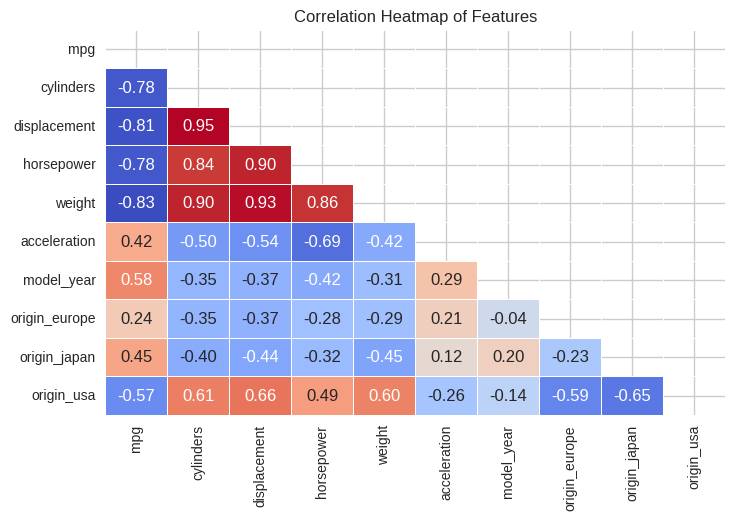

In [ ]:
plt.figure(figsize = (8,5))

mask = np.triu(np.ones_like(correlation_matrix, dtype = bool))

sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm',
            linewidths = 0.5, fmt = '.2f', annot_kws={"size": 12}, cbar = False, mask = mask)
plt.title("Correlation Heatmap of Features")
plt.show()


In [ ]:
# 2. scaled value of data or index 85
displacement_scaled_85 = df_scaled.loc[85, 'displacement']
displacement_scaled_85

np.float64(1.048584292818992)

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA

pca = PCA()
pca.fit(df_scaled)

explained_variance = pca.explained_variance_ratio_
components = pca.components_

# Display the explained variance and components

explained_variance, components

(array([0.57885753, 0.13297249, 0.11850505, 0.07328586, 0.05852549,
        0.01825335, 0.0112476 , 0.00530801, 0.00304462, 0.        ]),
 array([[-3.68203717e-01,  3.86894349e-01,  4.01424093e-01,
          3.79861114e-01,  3.85032556e-01, -2.47214254e-01,
         -1.92660853e-01, -1.60988643e-01, -2.13089870e-01,
          3.02481767e-01],
        [-1.52580773e-01, -4.32702688e-02, -4.01040260e-02,
          1.42386673e-02,  7.80536760e-03,  4.19827885e-02,
         -4.13815489e-01,  7.50831804e-01, -4.25698631e-01,
         -2.34523473e-01],
        [-4.75104736e-02,  2.00635457e-02,  1.42422130e-02,
          2.32913680e-01, -4.09429126e-02, -4.47132733e-01,
         -3.50776950e-01,  4.77795581e-03,  6.03595273e-01,
         -5.03875016e-01],
        [ 2.56082989e-01,  1.08264258e-01,  1.05105017e-01,
          2.05505495e-01,  1.13505686e-01, -4.37150629e-01,
          7.05838941e-01,  3.49921568e-01, -1.19643989e-01,
         -1.74551333e-01],
        [-1.50529154e-01,  2.51761

In [ ]:
# Answer 3, 4, and 5

3. Explained variance of PC0: **0.57**
4. Total explained variance of PC0 and PC1: **0.70**
5. Total explained variance of PC0, PC1, and PC2: **0.81**

In [ ]:
# 6. Project the original data onto the first two principal components

pca_2_components = PCA(n_components = 2)
data_pca_2_components = pca_2_components.fit_transform(df_scaled)

data_pca_2_components_df = pd.DataFrame(data_pca_2_components, columns = ['PC0', 'PC1'])
data_pca_2_components_df.loc[[285]]

,PC0,PC1
285,2.745641,-0.654101


In [ ]:
# 7. Project the original data onto the first three principal components
pca_3_components = PCA(n_components=3)
data_pca_3_components = pca_3_components.fit_transform(df_scaled)

data_pca_3_components_df = pd.DataFrame(data_pca_3_components, columns=['PC0', 'PC1', 'PC2'])
data_pca_3_components_df.loc[[300]]

,PC0,PC1,PC2
300,-1.601608,-0.826332,-1.145432


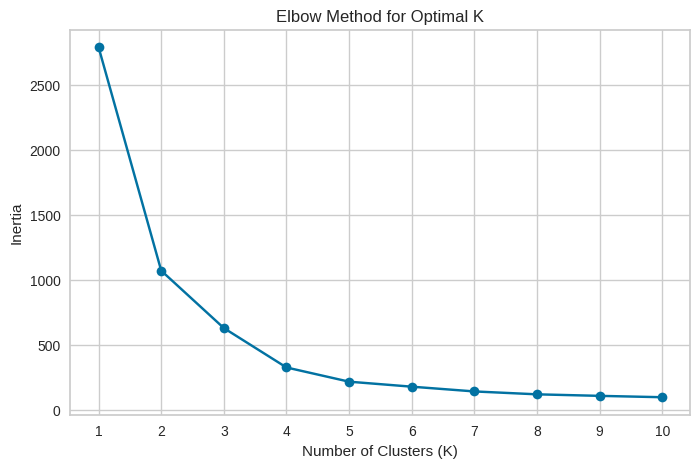

In [ ]:
# 8. KMeans Clustering
from sklearn.cluster import KMeans

# Select the first two principal components
df_pca_2d = data_pca_2_components[:, :2]

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=random_s, n_init='auto')
    kmeans.fit(df_pca_2d)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

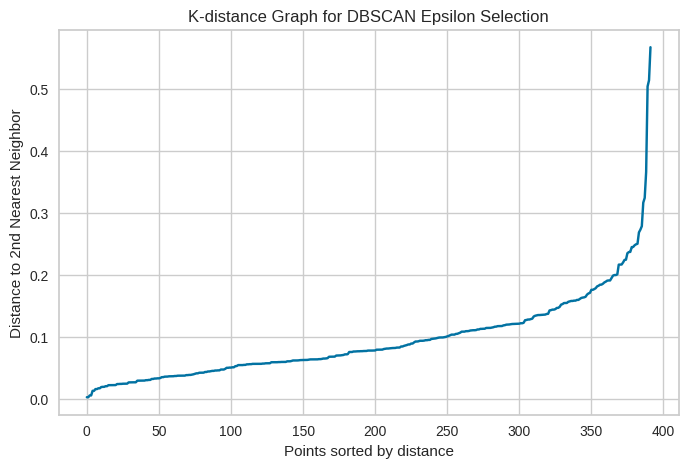

In [ ]:
# 9. DBSCAN Clustering
from sklearn.neighbors import NearestNeighbors

# Calculate distances to the nearest neighbor
neighbors = NearestNeighbors(n_neighbors=2*df_pca_2d.shape[1])
neighbors_fit = neighbors.fit(df_pca_2d)
distances, indices = neighbors_fit.kneighbors(df_pca_2d)

distances = np.sort(distances[:, 1], axis=0)
plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('Distance to 2nd Nearest Neighbor')
plt.title('K-distance Graph for DBSCAN Epsilon Selection')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.cluster import DBSCAN

optimal_epsilon = 0.5
min_samples_recommended = 4

dbscan = DBSCAN(eps=optimal_epsilon, min_samples=min_samples_recommended)
dbscan.fit(df_pca_2d)

# Get the cluster labels
labels = dbscan.labels_

n_outliers = list(labels).count(-1)

print(f"10. min_samples value: {min_samples_recommended}")
print(f"11. number of outliers: {n_outliers}")

10. min_samples value: 4
11. number of outliers: 6


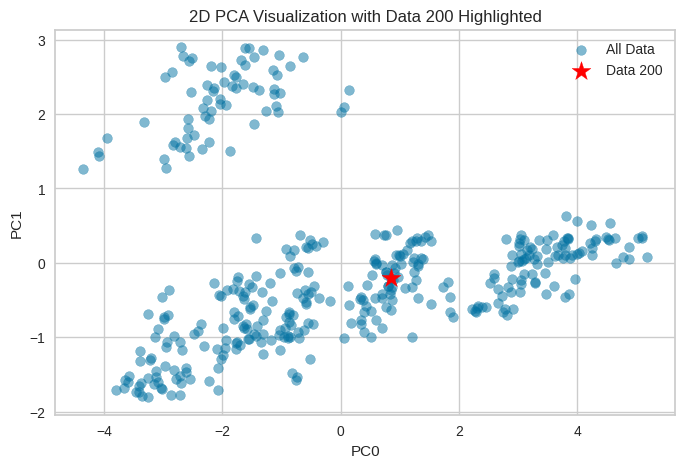

In [ ]:
# a. Visualize the x = PC0 and y = PC1, Show Data 200 with marker of star (*) using 2D scatter plot

plt.figure(figsize=(8, 5))
plt.scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], label='All Data', alpha=0.5)
plt.scatter(df_pca_2d[200, 0], df_pca_2d[200, 1], marker='*', color='red', s=200, label='Data 200')
plt.xlabel('PC0')
plt.ylabel('PC1')
plt.title('2D PCA Visualization with Data 200')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# b. Visualize the x = PC0, y = PC1, and z = PC2, Show or Trace Data 200 with black circle, using scatter_3D.

import plotly.express as px

fig = px.scatter_3d(
    x=data_pca_3_components[:, 0],
    y=data_pca_3_components[:, 1],
    z=data_pca_3_components[:, 2],
    title='3D PCA Visualization with Data 200',
    labels={'x': 'PC0', 'y': 'PC1', 'z': 'PC2'}
)

fig.add_scatter3d(
    x=[data_pca_3_components[200, 0]],
    y=[data_pca_3_components[200, 1]],
    z=[data_pca_3_components[200, 2]],
    mode='markers',
    marker=dict(
        color='black',
        size=10,
        symbol='circle'
    ),
    name='Data 200'
)

fig.show()

## Conclusion
A typical workflow for clustering analysis using PCA. We started by loading and cleaning the data, then applied PCA for dimensionality reduction. Finally, we explored different clustering algorithms like KMeans and DBSCAN, using the elbow method and k-distance graph respectively to determine optimal parameters, and visualized the results.